In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from pathlib import Path
from collections import Counter

In [7]:
layer_group = 'middle'
fnames = list(Path(layer_group).rglob('*adc.npy'))
fnames.sort()

for fname in fnames:
    adc = np.load(fname)
    if adc.max() > 0:
        print(fname, adc.max(), adc.sum())

middle/12-2_0-0/TPCMLDataInterface_1_adc.npy 698 27253
middle/12-2_0-0/TPCMLDataInterface_2_adc.npy 380 26678
middle/12-2_0-0/TPCMLDataInterface_9_adc.npy 78 371
middle/12-2_0-1/TPCMLDataInterface_1_adc.npy 78 374
middle/12-2_0-1/TPCMLDataInterface_2_adc.npy 78 373
middle/12-2_0-1/TPCMLDataInterface_9_adc.npy 389 29161
middle/12-2_1-0/TPCMLDataInterface_3_adc.npy 233 27352
middle/12-2_1-0/TPCMLDataInterface_6_adc.npy 251 33957
middle/12-2_1-0/TPCMLDataInterface_7_adc.npy 247 24417
middle/12-2_1-0/TPCMLDataInterface_9_adc.npy 79 1495
middle/12-2_1-1/TPCMLDataInterface_2_adc.npy 253 28840
middle/12-2_1-1/TPCMLDataInterface_6_adc.npy 244 24378
middle/12-2_1-1/TPCMLDataInterface_9_adc.npy 1011 202137
middle/12-2_10-0/TPCMLDataInterface_0_adc.npy 360 4350
middle/12-2_10-0/TPCMLDataInterface_8_adc.npy 95 3177
middle/12-2_10-0/TPCMLDataInterface_9_adc.npy 430 23039
middle/12-2_10-1/TPCMLDataInterface_0_adc.npy 1014 59603
middle/12-2_10-1/TPCMLDataInterface_3_adc.npy 180 17651
middle/12-2_10-1

In [8]:
def plot_3d(image, vmax=None):
    X, Y, Z = np.argwhere((image >= 1)).T
    values = image[X, Y, Z]
    
    if vmax:
        values[values > vmax] = vmax

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # Don't use normalize, just set range manually. 
    # It seems that it use up all memory. 
    # normalize = matplotlib.colors.Normalize(vmin=6, vmax=8)
    ax.scatter3D(
        X, Y, Z, 
        c=values, 
        s=1,
        cmap='Blues', 
    )
    ax.set_xlim(0, 192)
    ax.set_ylim(0, 249)
    ax.set_zlim(0, 16)
    plt.show()

(128, 249, 16)


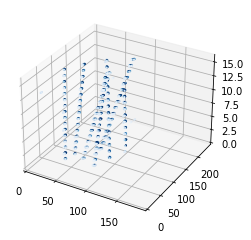

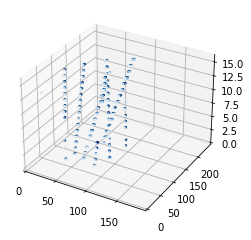

In [9]:
fname_adc = 'middle/12-2_1-1/TPCMLDataInterface_9_adc.npy'
fname_sbg = 'middle/12-2_1-1/TPCMLDataInterface_9_sbg.npy'
adc = np.load(fname_adc)
sbg = np.load(fname_sbg)
print(adc.shape)

plot_3d(adc, 100)
plot_3d(adc * sbg, 100)

In [10]:
fnames = list(Path('outer').rglob('*adc.npy'))
fnames.sort()
counter = {}
for fname in fnames:
    adc = np.load(fname)
    c = Counter(adc.flatten())
    counter.update(c)

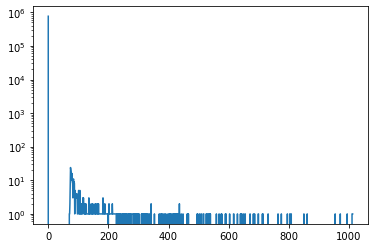

In [11]:
arr = [0] * (max(counter.keys()) + 1)
for key, val in counter.items():
    # print(key, val)
    arr[key] = val

plt.plot(range(len(arr)), arr)
plt.yscale('log')

In [12]:
zero = arr[0]
non_zero = sum(val for key, val in counter.items() if key > 0)
print(zero, non_zero)

764648 520
